# Decision Tree - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · classification**

Grow a 20-questions tree from scratch-math on REAL titanic data: compute Gini,
find the best split like sklearn does, and read the resulting rules.

### What you'll learn
- Gini impurity computed by hand on actual passenger groups
- How a split's quality is scored (impurity drop)
- Greedy recursion → a drawn tree you can read aloud
- Why unlimited depth memorizes

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    titanic = sns.load_dataset("titanic")
except Exception as e:
    print("offline?", e); raise

df = titanic.copy()
df["age"] = df["age"].fillna(df["age"].median())

### 1. Gini by hand on real groups

$$G = 1 - p_{\text{surv}}^2 - p_{\text{die}}^2$$

In [2]:
def gini(group):
    p = group.mean()
    return 1 - p**2 - (1-p)**2

root_gini = gini(df.survived)
women_gini = gini(df[df.sex == "female"].survived)
men_gini = gini(df[df.sex == "male"].survived)

print(f"Gini(all passengers)      = {root_gini:.4f}")
print(f"Gini(females only)        = {women_gini:.4f}")
print(f"Gini(males only)          = {men_gini:.4f}")

Gini(all passengers)      = 0.4730
Gini(females only)        = 0.3828
Gini(males only)          = 0.3064


### 2. Score candidate splits - impurity drop


In [3]:
def split_gain(mask):
    n = len(df)
    left, right = df[mask].survived, df[~mask].survived
    if len(left) == 0 or len(right) == 0:
        return 0
    return root_gini - (len(left)/n)*gini(left) - (len(right)/n)*gini(right)

candidates = {
    "sex == female":            df.sex == "female",
    "pclass <= 1":              df.pclass <= 1,
    "age <= 18":                df.age <= 18,
    "fare <= 30":               df.fare <= 30,
    "sibsp >= 1":               df.sibsp >= 1,
}
gains = {name: round(split_gain(mask), 4) for name, mask in candidates.items()}
gain_tbl = pd.Series(gains).sort_values(ascending=False).to_frame("gini_gain")
display(gain_tbl)

best_q = gain_tbl.index[0]
print(f"\nBEST first question: '{best_q}' - exactly what the greedy tree asks!")

,gini_gain
sex == female,0.1396
pclass <= 1,0.0387
fare <= 30,0.0277
sibsp >= 1,0.0064
age <= 18,0.0053



BEST first question: 'sex == female' — exactly what the greedy tree asks!


### 3. Grow & draw a real tree (depth 3 keeps it human-readable)


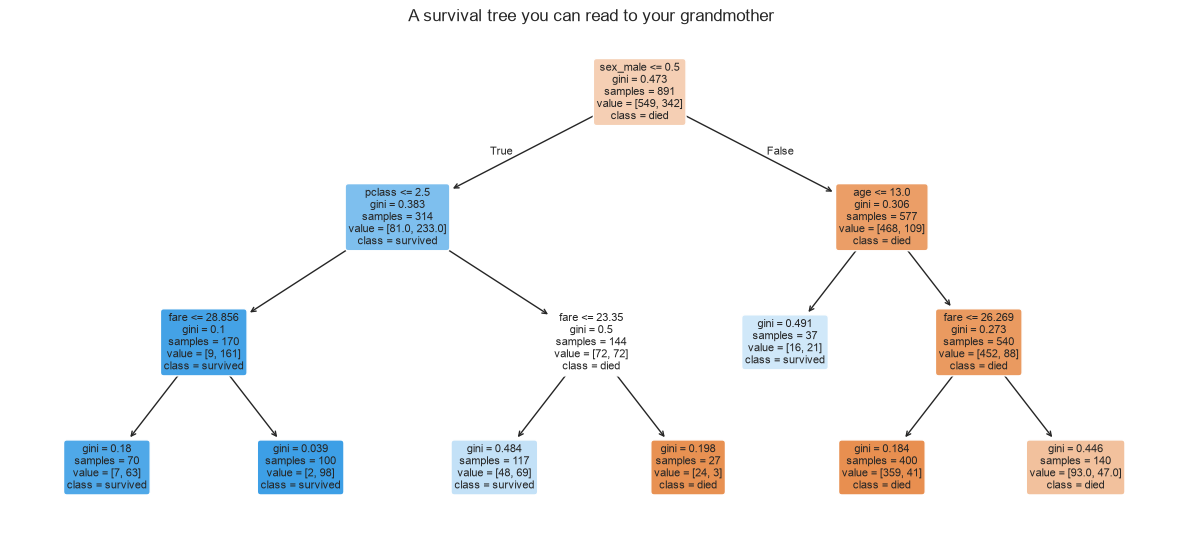

In [4]:
features = pd.get_dummies(
    df[["pclass", "sex", "age", "sibsp", "parch", "fare"]],
    columns=["sex"], drop_first=True)

tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=25,
                              random_state=42).fit(features, df.survived)

plt.figure(figsize=(15, 6.5))
plot_tree(tree, feature_names=features.columns,
          class_names=["died", "survived"], filled=True, rounded=True,
          fontsize=8, impurity=True)
plt.title("A survival tree you can read to your grandmother")
plt.show()

### Reading the picture

Every box: the asked question · gini of that node · samples reaching it ·
class mix. Path colors lean toward the winning class. Two paths survive depth
limits - deeper trees add nuance but start memorizing.

### 4. Unlimited depth = memorization machine


In [5]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(features, df.survived,
                                          test_size=.3, random_state=42,
                                          stratify=df.survived)
rows = []
for depth in [1, 2, 3, 5, 8, None]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_tr, y_tr)
    rows.append({"max_depth": str(depth),
                 "train acc": round(t.score(X_tr, y_tr), 3),
                 "test acc": round(t.score(X_te, y_te), 3)})
display(pd.DataFrame(rows))
print("train hits 100% while test peaks then decays → prune or ensemble.")

,max_depth,train acc,test acc
0,1,0.791,0.776
1,2,0.807,0.769
2,3,0.830,0.795
3,5,0.864,0.791
4,8,0.910,0.772
5,None,0.979,0.784


train hits 100% while test peaks then decays → prune or ensemble.


### Summary & key takeaways

- Splits maximize impurity drop; Gini/entropy both measure class mixing.
- Greedy recursion builds IF/ELSE rules anyone can audit.
- Depth controls the overfit dial; `min_samples_leaf` & `ccp_alpha` prune.
- Single trees wobble - averaging many of them (next modules) fixes that.